In [1]:
# Write your imports here
import numpy as np;
import matplotlib.pyplot as plt

# Physical constants
G_GRAVITY = 9.8  # m/s²
DEFAULT_TRUNK_LENGTH = 0.77  # m
DEFAULT_K_FACTOR = 0.27  # trunk moment arm factor
L5S1_LIMIT_N = 3400.0  # N, maximum compressive force at L5/S1



# Safe Lifting Analysis — Biomechanical Load Evaluation
Incorrect lifting often causes low back pain. This project explores the sagittal-plane lumbar load at L5-S1 using the model from *Biomechanical Waist Comfort Model for Lifting* (PDF).

## Abstract
Incorrect lifting often causes low back pain. This project develops and tests a static biomechanical model for manual lifting risk at the L5-S1 spinal segment. Using formulas adapted from *A Biomechanical Waist Comfort Model for Manual Material Lifting* (Zhang et al., 2020), we quantify erector spinae force, lifting index, and a comfort score as functions of object mass and lifting height.


## 1. Problem formulation and significance
Low-back pain is strongly associated with manual material handling. In ergonomics, the L5-S1 lumbar segment is commonly used as a risk-critical point.

### Research question
How do object weight and lifting height affect lumbar loading and safety margin during stoop lifting?

### Objectives
- Implement a reproducible biomechanical force model for L5-S1 loading.
- Compute recommended weight limit (RWL), lifting index (LI), and waist comfort score.
- Evaluate risk across realistic lifting configurations.
- Define risk metrics and analyze sensitivity across posture and object weight.
- Present results with clear bullets and plots.



## 2. Model equations and assumptions

### 2.1. Equilibrium condition
The net moment around the L5-S1 joint must be zero in static balance.

$$M = 0$$

Muscle force multiply its lever arm equals load moments:

where `F` is spinal muscle force, `L` is trunk lever arm and `G` is external load force. For simplified model we also analyze:

$$F \cdot L = G \cdot L_1 + F_{\mathrm{body}} \cdot L_{2}$$

Expanded form with trunk (F2) and head/armparts (F3) contributions. Static moment equilibrium at L5-S1:

$$F \cdot L = G \cdot L_1 + F_2 \cdot L_2 + F_3 \cdot L_3$$


### 2.2 Geometric relationships
Body and object geometry connect trunk inclination to moment arms:

$$\cos\alpha = \frac{H_2 + h - H_1}{L}$$

$$\sin\alpha = \sqrt{1 - \cos^2\alpha}$$

Moment arm relations:

$$L_1 = L_3 = L \sin\alpha,\qquad L_2 = k \, L \sin\alpha$$

### 2.3 Practical formula used in this notebook
Following the source paper parameterization Empirical lumbar load formula is: 

$$F = (3.42M + 9.06G)\,\sin\alpha$$

with

$$M = m_{body}g, \quad G = m_{object}g$$

and

$$\sin\alpha = \sqrt{1 - (0.37\,h/H - 0.63)^2}$$

where `h` is object center-of-mass height from ground and `H` is worker height.

When object load is zero:

$$G = 0 \quad \Rightarrow \quad F = 3.42 \cdot M \cdot \sin\alpha$$

### 2.4 RWL and risk metrics
We use an adjusted RWL form (as in the paper's adaptation):

$$RWL(h)=20\,(1-0.003|h-72|)\left(0.82+\frac{4.5}{74-h}\right)\,0.90$$

Then:

- `LI = m_object / RWL(h)`
- `F_RWL = F(m_object = RWL(h))`
- `Comfort C = 1 - F / F_RWL`

Interpretation:
- `LI < 1` and `C > 0`: acceptable
- `LI = 1` and `C = 0`: limit condition
- `LI > 1` and `C < 0`: elevated risk

### 2.5 NIOSH context
- NIOSH recommended limit: 3400 N at L5-S1.
- Simplified RWL form used as quality check: `RWL = W H D V F A C`.


<div style="display: flex; gap: 8px; align-items: center;">
  <img src="images/Biom1.jpg" alt="Biom1" width="200" height="300" >
  <img src="images/Biom2.jpg" alt="Biom2" width="200" height="300" >
  <img src="images/Biom3.jpg" alt="Biom3" width="200" height="300">
  <img src="images/Biom4.jpg" alt="Biom4" width="200" height="300">
</div>

## 3. Symbols list

- $M$ - body weight force at L5-S1 (N), $M = m_{body} * g$
- $G$ - object force (N), $G = m_{object} * g$
- $g$ - gravity force = 9.8 $m / s^2$
- $F$ - erector spinae muscle force needed for equilibrium (N)
- $L$ - trunk lever arm (m), $L1,L2,L3$: moment arm projections (m)
- $H$ - total height (cm), $H1$: L5-S1 height (cm), $H2$: upper body height (cm), $h$: object height (cm)
- $α$ - trunk angle 
- $k$ - proportion factors
- $j$ - body segment mass fraction

## 4. Core implementation

In [2]:
## 4. Core implementation

def sin_alpha_from_h(h_cm, H_cm=168.0):
    """Compute sin(alpha) from height relation in the source paper."""
    x = 0.37 * h_cm / H_cm - 0.63
    return np.sqrt(np.clip(1.0 - x**2, 0.0, 1.0))


def erector_force_N(m_body_kg, m_object_kg, h_cm, H_cm=168.0, g=G_GRAVITY):
    M = m_body_kg * g
    G = m_object_kg * g
    s = sin_alpha_from_h(h_cm=h_cm, H_cm=H_cm)
    return (3.42 * M + 9.06 * G) * s


def rwl_kg(h_cm):
    """Adjusted RWL formula (paper adaptation for the selected context)."""
    denom = np.maximum(74.0 - h_cm, 1e-6)
    return 20.0 * (1.0 - 0.003 * np.abs(h_cm - 72.0)) * (0.82 + 4.5 / denom) * 0.90


def lifting_index(m_object_kg, h_cm):
    return m_object_kg / rwl_kg(h_cm)


def comfort_score(m_body_kg, m_object_kg, h_cm, H_cm=168.0):
    F = erector_force_N(m_body_kg, m_object_kg, h_cm, H_cm)
    F_rwl = erector_force_N(m_body_kg, rwl_kg(h_cm), h_cm, H_cm)
    return 1.0 - (F / np.maximum(F_rwl, 1e-9))


def l5s1_resultant_N(m_body_kg, m_object_kg, h_cm, H_cm=168.0, g=G_GRAVITY):
    """Approximate resultant force using normal and shear decomposition."""
    s = sin_alpha_from_h(h_cm=h_cm, H_cm=H_cm)
    c = np.sqrt(np.clip(1.0 - s**2, 0.0, 1.0))
    M = m_body_kg * g
    G = m_object_kg * g
    F = erector_force_N(m_body_kg, m_object_kg, h_cm, H_cm, g)
    sigma = F + (0.47 * M + G) * c
    tau = (0.47 * M + G) * s
    return np.sqrt(sigma**2 + tau**2)

## 5. Baseline scenario demonstration

In [3]:
## Baseline scenario demonstration
baseline = {
    "m_body_kg": 59.0,
    "m_object_kg": 12.0,
    "h_cm": 45.0,
    "H_cm": 168.0,
}

F_base = erector_force_N(**baseline)
LI_base = lifting_index(baseline["m_object_kg"], baseline["h_cm"])
C_base = comfort_score(baseline["m_body_kg"], baseline["m_object_kg"], baseline["h_cm"], baseline["H_cm"])
N_base = l5s1_resultant_N(**baseline)

print("Baseline case")
print(f"F (erector force): {F_base:.1f} N")
print(f"Estimated L5-S1 resultant N: {N_base:.1f} N")
print(f"Lifting index LI: {LI_base:.2f}")
print(f"Comfort score C: {C_base:.3f}")
print("L5-S1 status:", "acceptable" if N_base < L5S1_LIMIT_N else "high risk")

Baseline case
F (erector force): 2578.7 N
Estimated L5-S1 resultant N: 2804.9 N
Lifting index LI: 0.74
Comfort score C: 0.108
L5-S1 status: acceptable


Max |C| when m_object = RWL: 0.0


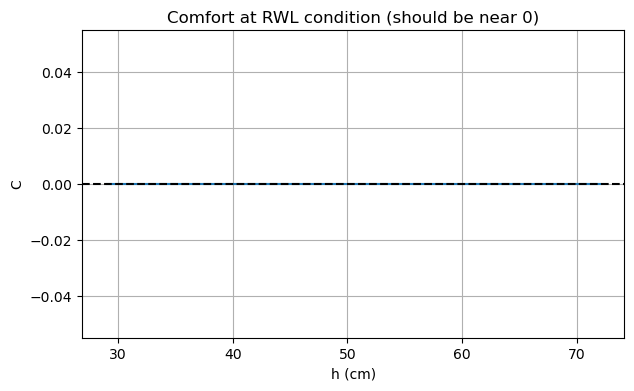

In [4]:
# Validation: comfort is ~0 at RWL
h_check = np.linspace(29, 72, 100)
C_vals = np.array([comfort_score(59.0, rwl_kg(h), h, 168.0) for h in h_check])
print("Max |C| when m_object = RWL:", np.max(np.abs(C_vals)))

plt.figure(figsize=(7, 4))
plt.plot(h_check, C_vals)
plt.axhline(0.0, linestyle="--", color="black")
plt.title("Comfort at RWL condition (should be near 0)")
plt.xlabel("h (cm)")
plt.ylabel("C")
plt.grid(True)
plt.show()

## 6. Experimental design
